# 路线偏好训练数据诊断

这个 notebook 用于判断当前路线偏好 MLP 是应该继续调参，还是优先补数据。

- 只读 PostgreSQL 和训练产物，不写数据库。
- 复用 `training/` 里的数据构造、candidate_set 切分和模型定义，避免诊断口径和训练口径不一致。
- 图表重点看 candidate set 数量、pair 数量、accepted/rejected 分布、reason code 支持度、训练 history，以及当前模型的 reason 分数分布。


In [9]:
from __future__ import annotations

from collections import Counter, defaultdict
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display

try:
    import pandas as pd
except ImportError:
    pd = None


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "AGENTS.md").exists() and (path / "ai-python" / "src").exists():
            return path
    raise RuntimeError("找不到项目根目录，请从 urban-sidequest 项目内打开 notebook。")


PROJECT_ROOT = find_project_root()
SRC_ROOT = PROJECT_ROOT / "ai-python" / "src"
SRC_ROOT_TEXT = str(SRC_ROOT)
sys.path = [SRC_ROOT_TEXT] + [entry for entry in sys.path if entry != SRC_ROOT_TEXT]
for module_name in list(sys.modules):
    if module_name == "urban_sidequest_ai" or module_name.startswith("urban_sidequest_ai."):
        del sys.modules[module_name]

OUTPUT_DIR = PROJECT_ROOT / "tmp" / "route-pref-training-output"
FEATURE_SCHEMA_VERSION = "route_pref_v5"
SEED = 42

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


def show_table(rows: list[dict], title: str | None = None, sort_by: str | None = None):
    if title:
        display(Markdown(f"### {title}"))
    if not rows:
        display(Markdown("无数据"))
        return None
    if pd is not None:
        frame = pd.DataFrame(rows)
        if sort_by and sort_by in frame.columns:
            frame = frame.sort_values(sort_by, ascending=False)
        display(frame)
        return frame
    for row in rows:
        print(row)
    return rows


display(Markdown(f"项目根目录：`{PROJECT_ROOT}`"))
display(Markdown(f"训练产物目录：`{OUTPUT_DIR}`"))


项目根目录：`/Users/qinzeyu/study/mix-java-python/urban-sidequest`

训练产物目录：`/Users/qinzeyu/study/mix-java-python/urban-sidequest/tmp/route-pref-training-output`

In [10]:
from urban_sidequest_ai.models.route_preference.training.db import connect, load_database_config
from urban_sidequest_ai.models.route_preference.training.dataset import (
    build_dataset_bundle,
    iter_batches,
    split_by_candidate_set,
)
from urban_sidequest_ai.models.route_preference.training.model import RoutePreferenceModel, RoutePreferenceModelConfig
from urban_sidequest_ai.models.route_preference.training.repository import RoutePreferenceTrainingRepository
from urban_sidequest_ai.models.route_preference.training.schema import (
    DEFAULT_GOOD_ROUTE_THRESHOLD,
    DEFAULT_HIGH_ISSUE_THRESHOLD,
    DEFAULT_ISSUE_THRESHOLD,
    InvalidJudgmentPolicy,
    REASON_CODES,
)


def load_bundle():
    db_config = load_database_config()
    with connect(db_config) as connection:
        repository = RoutePreferenceTrainingRepository(connection)
        sample_rows = repository.fetch_training_samples(FEATURE_SCHEMA_VERSION)
        judgment_rows = repository.fetch_completed_judgments({row.candidate_set_id for row in sample_rows})
    bundle = build_dataset_bundle(sample_rows, judgment_rows, InvalidJudgmentPolicy.FAIL)
    splits = split_by_candidate_set(bundle.groups, seed=SEED)
    return sample_rows, judgment_rows, bundle, splits


sample_rows, judgment_rows, bundle, splits = load_bundle()
SPLIT_GROUPS = {
    "train": splits.train,
    "valid": splits.valid,
    "test": splits.test,
}

display(Markdown(f"读取训练样本 `{len(sample_rows)}` 行，completed judgments `{len(judgment_rows)}` 条，可训练 candidate sets `{len(bundle.groups)}` 组。"))
if bundle.skipped_judgments:
    display(Markdown(f"跳过 judgment 数：`{len(bundle.skipped_judgments)}`"))
    for message in bundle.skipped_judgments[:10]:
        print(message)


读取训练样本 `9226` 行，completed judgments `3649` 条，可训练 candidate sets `1929` 组。

### Split 总览

,split,candidate_sets,routes,pairs,avg_routes_per_set,avg_pairs_per_set,accepted_routes,rejected_routes,goodness_labeled_routes,reason_labeled_routes
0,train,1380,6625,10914,4.80,7.91,2529,2611,5140,2611
1,valid,303,1429,2336,4.72,7.71,533,584,1117,584
2,test,246,1156,1900,4.70,7.72,446,450,896,450


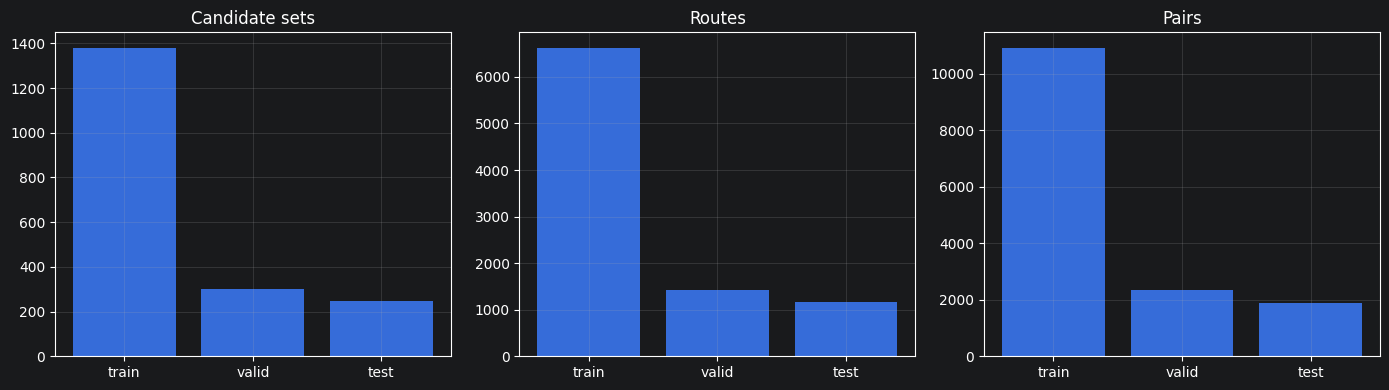

In [11]:
def summarize_split(groups):
    route_count = sum(len(group.items) for group in groups)
    pair_count = sum(len(group.pairs) for group in groups)
    accepted_count = sum(1 for group in groups for item in group.items if item.is_accepted)
    rejected_count = sum(1 for group in groups for item in group.items if item.is_rejected)
    goodness_labeled = sum(1 for group in groups for item in group.items if item.goodness_mask)
    reason_labeled = sum(1 for group in groups for item in group.items if item.reason_mask)
    return {
        "candidate_sets": len(groups),
        "routes": route_count,
        "pairs": pair_count,
        "avg_routes_per_set": round(route_count / len(groups), 2) if groups else 0.0,
        "avg_pairs_per_set": round(pair_count / len(groups), 2) if groups else 0.0,
        "accepted_routes": accepted_count,
        "rejected_routes": rejected_count,
        "goodness_labeled_routes": goodness_labeled,
        "reason_labeled_routes": reason_labeled,
    }


split_rows = [{"split": split_name, **summarize_split(groups)} for split_name, groups in SPLIT_GROUPS.items()]
show_table(split_rows, "Split 总览")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = [row["split"] for row in split_rows]
axes[0].bar(x, [row["candidate_sets"] for row in split_rows])
axes[0].set_title("Candidate sets")
axes[1].bar(x, [row["routes"] for row in split_rows])
axes[1].set_title("Routes")
axes[2].bar(x, [row["pairs"] for row in split_rows])
axes[2].set_title("Pairs")
plt.tight_layout()
plt.show()


In [12]:
def distribution_rows(counter: Counter, key_name: str, split_name: str):
    total = sum(counter.values())
    return [
        {
            "split": split_name,
            key_name: key,
            "count": count,
            "pct": round(count / total, 4) if total else 0.0,
        }
        for key, count in counter.items()
    ]


judge_rows = []
for split_name, groups in SPLIT_GROUPS.items():
    judge_rows.extend(distribution_rows(Counter(group.judge_type for group in groups), "judge_type", split_name))

show_table(judge_rows, "judge_type 分布", "count")


### judge_type 分布

,split,judge_type,count,pct
0,train,LLM_SIM_USER,1380,1.0
1,valid,LLM_SIM_USER,303,1.0
2,test,LLM_SIM_USER,246,1.0


,split,judge_type,count,pct
0,train,LLM_SIM_USER,1380,1.0
1,valid,LLM_SIM_USER,303,1.0
2,test,LLM_SIM_USER,246,1.0


### train 每条 rejected route 的 reason 数量

,split,active_reason_count_per_route,routes
0,train,1,323
1,train,2,1011
2,train,3,752
3,train,4,354
4,train,5,129
5,train,6,39
6,train,7,3


### valid 每条 rejected route 的 reason 数量

,split,active_reason_count_per_route,routes
0,valid,1,71
1,valid,2,238
2,valid,3,163
3,valid,4,75
4,valid,5,28
5,valid,6,7
6,valid,7,2


### test 每条 rejected route 的 reason 数量

,split,active_reason_count_per_route,routes
0,test,1,57
1,test,2,171
2,test,3,126
3,test,4,58
4,test,5,31
5,test,6,6
6,test,7,1


### reason code 正样本支持度

,split,reason_code,positive_routes,positive_rate_in_reason_routes,positive_rate_in_rejected
3,train,HIGH_FATIGUE,1107,0.4240,0.4240
0,train,LOW_INTEREST_COVERAGE,1106,0.4236,0.4236
6,train,REPETITIVE_POI_TYPE,969,0.3711,0.3711
2,train,BAD_TIME_STRUCTURE,836,0.3202,0.3202
1,train,WEAK_GOAL_FIT,769,0.2945,0.2945
7,train,BUDGET_MISMATCH,731,0.2800,0.2800
5,train,LOW_ROUTE_DIVERSITY,690,0.2643,0.2643
4,train,BAD_SPATIAL_FLOW,551,0.2110,0.2110
9,valid,LOW_INTEREST_COVERAGE,249,0.4264,0.4264
12,valid,HIGH_FATIGUE,236,0.4041,0.4041


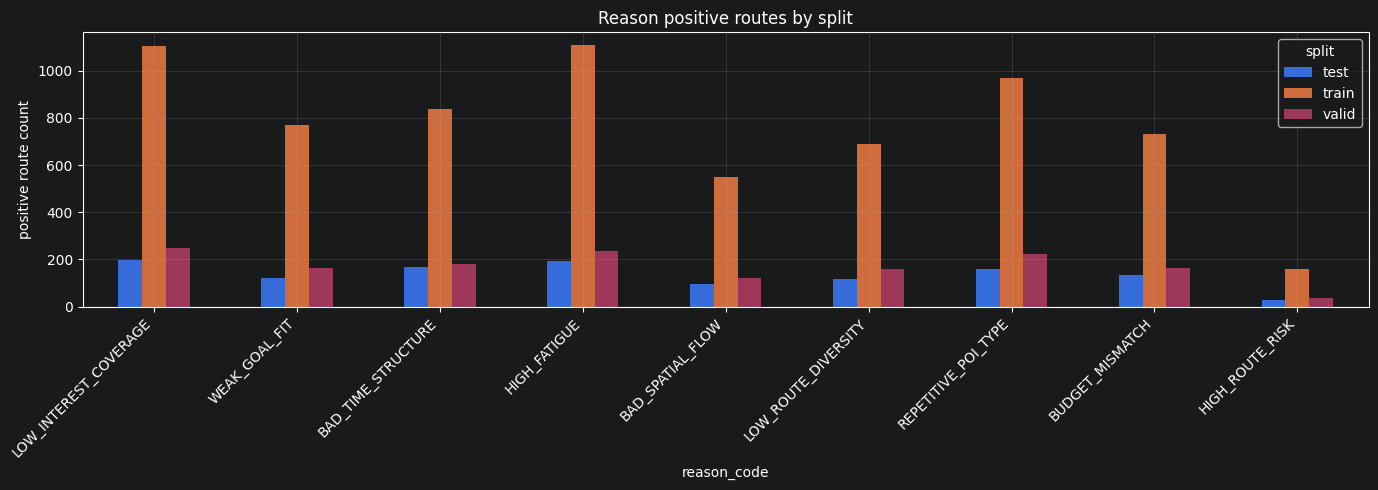

In [13]:
reason_rows = []
for split_name, groups in SPLIT_GROUPS.items():
    reason_route_count = sum(1 for group in groups for item in group.items if item.reason_mask)
    rejected_count = sum(1 for group in groups for item in group.items if item.is_rejected)
    positives = Counter()
    cooccurrence = Counter()
    for group in groups:
        for item in group.items:
            if not item.reason_mask:
                continue
            active_codes = [REASON_CODES[index] for index, value in enumerate(item.reason_labels) if value >= 0.5]
            positives.update(active_codes)
            cooccurrence[len(active_codes)] += 1
    for code in REASON_CODES:
        count = positives[code]
        reason_rows.append(
            {
                "split": split_name,
                "reason_code": code,
                "positive_routes": count,
                "positive_rate_in_reason_routes": round(count / reason_route_count, 4) if reason_route_count else 0.0,
                "positive_rate_in_rejected": round(count / rejected_count, 4) if rejected_count else 0.0,
            }
        )
    show_table(
        [{"split": split_name, "active_reason_count_per_route": key, "routes": value} for key, value in sorted(cooccurrence.items())],
        f"{split_name} 每条 rejected route 的 reason 数量",
    )

reason_frame = show_table(reason_rows, "reason code 正样本支持度", "positive_routes")

if pd is not None:
    pivot = reason_frame.pivot(index="reason_code", columns="split", values="positive_routes").fillna(0)
    pivot.loc[list(REASON_CODES)].plot(kind="bar", figsize=(14, 5))
    plt.title("Reason positive routes by split")
    plt.ylabel("positive route count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

low_support = [row for row in reason_rows if row["split"] == "train" and row["positive_routes"] < 30]
if low_support:
    display(Markdown("### 训练集低支持度 reason code（正样本 < 30）"))
    show_table(low_support, sort_by="positive_routes")


### pair 类型与权重分布

,split,pair_type,pairs,weight_min,weight_mean,weight_max
0,train,aggregated,10914,0.0250,0.8225,3.156
1,valid,aggregated,2336,0.0475,0.8329,3.096
2,test,aggregated,1900,0.0580,0.8454,3.132


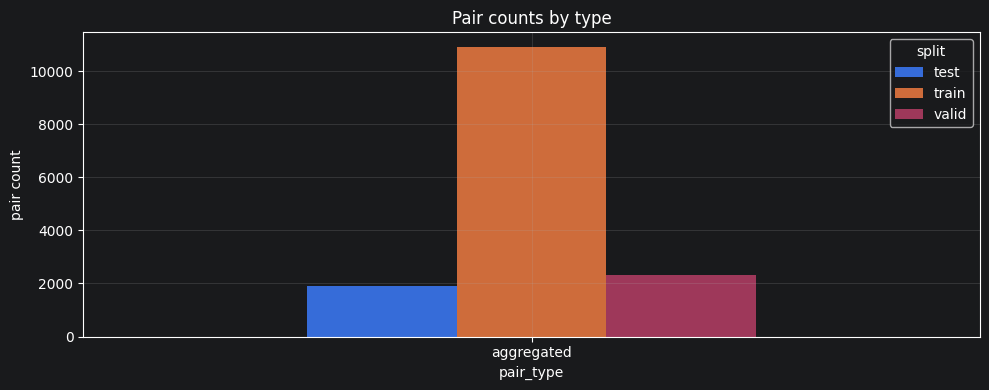

In [14]:
pair_rows = []
for split_name, groups in SPLIT_GROUPS.items():
    pair_type_counter = Counter(pair.pair_type for group in groups for pair in group.pairs)
    weights_by_type = defaultdict(list)
    for group in groups:
        for pair in group.pairs:
            weights_by_type[pair.pair_type].append(pair.weight_raw)
    for pair_type, count in pair_type_counter.items():
        weights = weights_by_type[pair_type]
        pair_rows.append(
            {
                "split": split_name,
                "pair_type": pair_type,
                "pairs": count,
                "weight_min": round(min(weights), 4),
                "weight_mean": round(sum(weights) / len(weights), 4),
                "weight_max": round(max(weights), 4),
            }
        )

pair_frame = show_table(pair_rows, "pair 类型与权重分布", "pairs")
if pd is not None:
    pair_frame.pivot(index="pair_type", columns="split", values="pairs").fillna(0).plot(kind="bar", figsize=(10, 4))
    plt.title("Pair counts by type")
    plt.ylabel("pair count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


### 最近 5 个 epoch

,epoch,lr,train/loss/goodness,train/loss/ranking,train/loss/reason,train/loss/total,valid/acceptedReasonFalsePositiveRate@issueThreshold,valid/goodnessAccuracy@0.5,valid/goodnessAuc,valid/goodnessPrAuc,...,valid/reasonAuc/LOW_ROUTE_DIVERSITY,valid/reasonAuc/REPETITIVE_POI_TYPE,valid/reasonAuc/WEAK_GOAL_FIT,valid/reasonConditionalMacroF1@0.5,valid/reasonConditionalMicroF1@0.5,valid/reasonConditionalPerCodeAucMacro,valid/reasonTopIssueHitRate,valid/top1Accuracy,valid/top2HitRate,valid/weightedPairwiseAccuracy
0,8,0.000359,0.502617,0.401311,0.813652,0.784247,0.987741,0.691264,0.753229,0.717976,...,0.565754,0.578784,0.600704,0.460429,0.518519,0.661826,0.615132,0.466667,0.723810,0.765565
1,9,0.000275,0.479403,0.381828,0.812620,0.750732,0.984238,0.701442,0.758503,0.720050,...,0.562059,0.572806,0.599598,0.464575,0.522208,0.658991,0.626645,0.485714,0.742857,0.774234
2,10,0.000203,0.467526,0.357435,0.810325,0.718983,0.989492,0.699746,0.754079,0.716270,...,0.561465,0.571106,0.596868,0.464693,0.521807,0.659412,0.626645,0.479365,0.733333,0.769573
3,11,0.000147,0.463191,0.357117,0.810345,0.716067,0.985989,0.696353,0.754205,0.716561,...,0.564856,0.576098,0.599109,0.469142,0.527188,0.662933,0.620066,0.463492,0.726984,0.768468
4,12,0.000112,0.456958,0.354818,0.809240,0.709916,0.980736,0.696353,0.754174,0.713646,...,0.566044,0.577477,0.595935,0.468515,0.525688,0.663570,0.625000,0.463492,0.720635,0.769280


### 关键指标最佳 epoch

,metric,best_epoch,best_value
0,valid/loss/total,6,0.905363
1,valid/loss/ranking,6,0.492750
2,valid/loss/goodness,7,0.548959
3,valid/loss/reason,8,0.812237
4,valid/weightedPairwiseAccuracy,9,0.774234
5,valid/ndcg@3,9,0.862633
6,valid/reasonConditionalMicroF1@0.5,6,0.527511
7,valid/reasonConditionalPerCodeAucMacro,12,0.663570


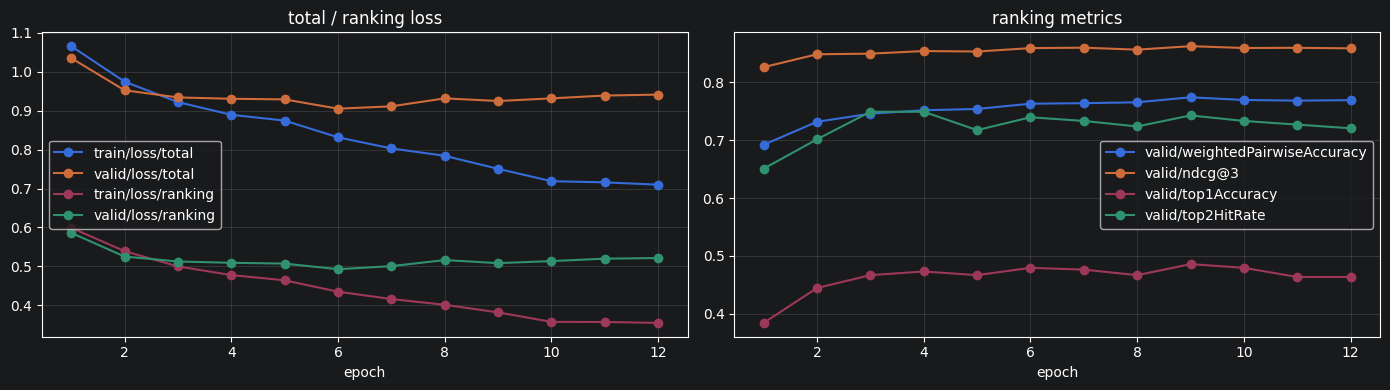

In [15]:
history_path = OUTPUT_DIR / "history.jsonl"
if not history_path.exists():
    display(Markdown(f"没有找到训练历史：`{history_path}`"))
else:
    history_rows = [json.loads(line) for line in history_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    history_frame = pd.DataFrame(history_rows) if pd is not None else history_rows
    show_table(history_rows[-5:], "最近 5 个 epoch")

    if pd is not None:
        metrics = [
            "valid/loss/total",
            "valid/loss/ranking",
            "valid/loss/goodness",
            "valid/loss/reason",
            "valid/weightedPairwiseAccuracy",
            "valid/ndcg@3",
            "valid/reasonConditionalMicroF1@0.5",
            "valid/reasonConditionalPerCodeAucMacro",
        ]
        best_rows = []
        for metric in metrics:
            if metric not in history_frame:
                continue
            idx = history_frame[metric].idxmin() if "/loss/" in metric else history_frame[metric].idxmax()
            best_rows.append({"metric": metric, "best_epoch": int(history_frame.loc[idx, "epoch"]), "best_value": history_frame.loc[idx, metric]})
        show_table(best_rows, "关键指标最佳 epoch")

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for key in ["train/loss/total", "valid/loss/total", "train/loss/ranking", "valid/loss/ranking"]:
            if key in history_frame:
                axes[0].plot(history_frame["epoch"], history_frame[key], marker="o", label=key)
        axes[0].set_title("total / ranking loss")
        axes[0].set_xlabel("epoch")
        axes[0].legend()

        for key in ["valid/weightedPairwiseAccuracy", "valid/ndcg@3", "valid/top1Accuracy", "valid/top2HitRate"]:
            if key in history_frame:
                axes[1].plot(history_frame["epoch"], history_frame[key], marker="o", label=key)
        axes[1].set_title("ranking metrics")
        axes[1].set_xlabel("epoch")
        axes[1].legend()
        plt.tight_layout()
        plt.show()


### 当前模型 reason 分数阈值诊断

,split,accepted_routes,accepted_runtime_issue_rate,accepted_max_reason_p50,accepted_max_reason_p90,accepted_max_reason_>=0.5,accepted_max_reason_>=0.8,rejected_labeled_reason_p50,rejected_labeled_reason_p90
0,train,2529,0.2357,0.6272,0.7405,0.9806,0.0613,0.6600,0.8915
1,valid,533,0.2233,0.6304,0.7318,0.9812,0.0488,0.6602,0.8803
2,test,446,0.2399,0.6325,0.7467,0.9776,0.0650,0.6729,0.8902


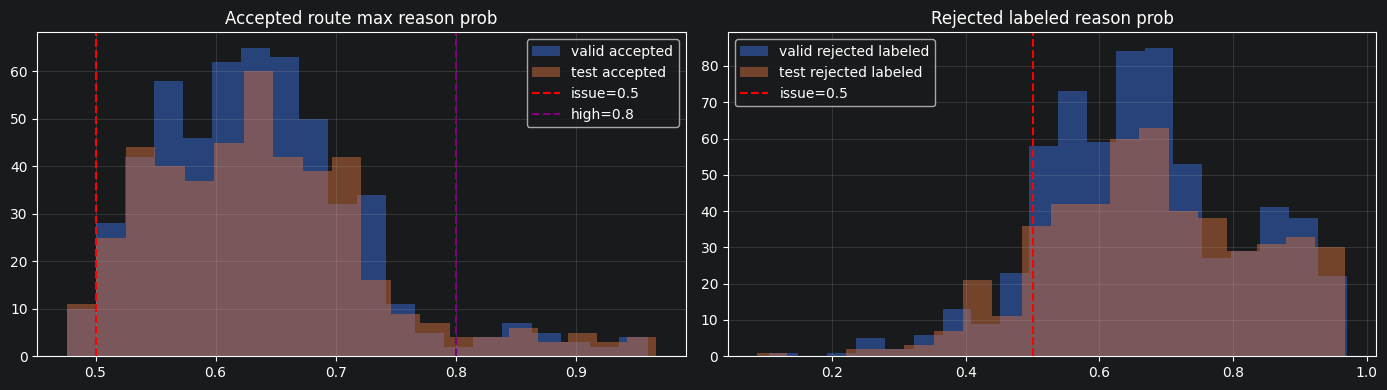

In [16]:
def percentile(values: list[float], q: float) -> float:
    if not values:
        return 0.0
    ordered = sorted(values)
    pos = (len(ordered) - 1) * q
    lo = int(pos)
    hi = min(lo + 1, len(ordered) - 1)
    frac = pos - lo
    return ordered[lo] * (1 - frac) + ordered[hi] * frac


def model_config_from_checkpoint(payload: dict) -> RoutePreferenceModelConfig:
    config = payload["modelConfig"]
    return RoutePreferenceModelConfig(
        route_derived_dim=config["routeDerivedDim"],
        context_cross_dim=config["contextCrossDim"],
        intra_set_dim=config.get("intraSetDim", 0),
        stop_dim=config["stopDim"],
        segment_dim=config["segmentDim"],
        max_stops=config["maxStops"],
        max_segments=config["maxSegments"],
        hidden_dim=config["hiddenDim"],
        dropout=config["dropout"],
        reason_hidden_dim=config["reasonHiddenDim"],
        reason_count=config["reasonCount"],
    )


def current_model_reason_distribution(groups):
    checkpoint_path = OUTPUT_DIR / "route-preference.pt"
    if not checkpoint_path.exists():
        return None
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    model = RoutePreferenceModel(model_config_from_checkpoint(checkpoint))
    model.load_state_dict(checkpoint["stateDict"])
    model.eval()

    rows = []
    with torch.no_grad():
        for split_name, split_groups in groups.items():
            for group in split_groups:
                batch = next(iter_batches((group,), 1, shuffle=False, seed=SEED, device=torch.device("cpu")))
                output = model(
                    batch.stop_matrix,
                    batch.segment_matrix,
                    batch.route_derived_vector,
                    batch.context_cross_vector,
                    batch.intra_set_vector,
                )
                goodness_probs = torch.sigmoid(output.route_goodness_logit).cpu().tolist()
                reason_probs = torch.sigmoid(output.reason_code_logits).cpu().tolist()
                for index, item in enumerate(group.items):
                    max_reason = max(reason_probs[index]) if reason_probs[index] else 0.0
                    labeled_reason_scores = [reason_probs[index][code_index] for code_index, value in enumerate(item.reason_labels) if value >= 0.5]
                    runtime_threshold = DEFAULT_HIGH_ISSUE_THRESHOLD if goodness_probs[index] >= DEFAULT_GOOD_ROUTE_THRESHOLD else DEFAULT_ISSUE_THRESHOLD
                    rows.append(
                        {
                            "split": split_name,
                            "candidate_set_id": group.candidate_set_id,
                            "route_code": item.route_code,
                            "is_accepted": item.is_accepted,
                            "is_rejected": item.is_rejected,
                            "goodness_prob": goodness_probs[index],
                            "max_reason_prob": max_reason,
                            "max_labeled_reason_prob": max(labeled_reason_scores) if labeled_reason_scores else None,
                            "runtime_has_issue": max_reason >= runtime_threshold,
                        }
                    )
    return rows


score_rows = current_model_reason_distribution(SPLIT_GROUPS)
if score_rows is None:
    display(Markdown(f"没有找到当前模型：`{OUTPUT_DIR / 'route-preference.pt'}`"))
else:
    summary_rows = []
    for split_name in ["train", "valid", "test"]:
        accepted = [row for row in score_rows if row["split"] == split_name and row["is_accepted"]]
        rejected = [row for row in score_rows if row["split"] == split_name and row["is_rejected"]]
        accepted_max = [row["max_reason_prob"] for row in accepted]
        rejected_labeled = [row["max_labeled_reason_prob"] for row in rejected if row["max_labeled_reason_prob"] is not None]
        summary_rows.append(
            {
                "split": split_name,
                "accepted_routes": len(accepted),
                "accepted_runtime_issue_rate": round(sum(row["runtime_has_issue"] for row in accepted) / len(accepted), 4) if accepted else 0.0,
                "accepted_max_reason_p50": round(percentile(accepted_max, 0.50), 4),
                "accepted_max_reason_p90": round(percentile(accepted_max, 0.90), 4),
                "accepted_max_reason_>=0.5": round(sum(value >= 0.5 for value in accepted_max) / len(accepted_max), 4) if accepted_max else 0.0,
                "accepted_max_reason_>=0.8": round(sum(value >= 0.8 for value in accepted_max) / len(accepted_max), 4) if accepted_max else 0.0,
                "rejected_labeled_reason_p50": round(percentile(rejected_labeled, 0.50), 4),
                "rejected_labeled_reason_p90": round(percentile(rejected_labeled, 0.90), 4),
            }
        )
    show_table(summary_rows, "当前模型 reason 分数阈值诊断")

    if pd is not None:
        score_frame = pd.DataFrame(score_rows)
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for split_name in ["valid", "test"]:
            values = score_frame[(score_frame["split"] == split_name) & (score_frame["is_accepted"] == True)]["max_reason_prob"]
            axes[0].hist(values, bins=20, alpha=0.5, label=f"{split_name} accepted")
        axes[0].axvline(DEFAULT_ISSUE_THRESHOLD, color="red", linestyle="--", label="issue=0.5")
        axes[0].axvline(DEFAULT_HIGH_ISSUE_THRESHOLD, color="purple", linestyle="--", label="high=0.8")
        axes[0].set_title("Accepted route max reason prob")
        axes[0].legend()

        for split_name in ["valid", "test"]:
            values = score_frame[(score_frame["split"] == split_name) & score_frame["max_labeled_reason_prob"].notna()]["max_labeled_reason_prob"]
            axes[1].hist(values, bins=20, alpha=0.5, label=f"{split_name} rejected labeled")
        axes[1].axvline(DEFAULT_ISSUE_THRESHOLD, color="red", linestyle="--", label="issue=0.5")
        axes[1].set_title("Rejected labeled reason prob")
        axes[1].legend()
        plt.tight_layout()
        plt.show()


### 按共识名次差分桶的 pairwise 准确率（gap=1 最相邻、最难）

,split,overall,gap=1,gap=2,gap=3,gap=4,gap=5
0,train,0.7752,0.665 (n=3373),0.774 (n=3845),0.861 (n=2505),0.912 (n=1191),—
1,valid,0.7693,0.664 (n=741),0.774 (n=817),0.845 (n=530),0.907 (n=248),—
2,test,0.7921,0.676 (n=611),0.806 (n=661),0.867 (n=427),0.940 (n=201),—


/var/folders/_8/dmjkj5ln757c_b551xmxk8dm0000gn/T/ipykernel_27307/4258647802.py:85: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_8/dmjkj5ln757c_b551xmxk8dm0000gn/T/ipykernel_27307/4258647802.py:85: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_8/dmjkj5ln757c_b551xmxk8dm0000gn/T/ipykernel_27307/4258647802.py:85: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_8/dmjkj5ln757c_b551xmxk8dm0000gn/T/ipykernel_27307/4258647802.py:85: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_8/dmjkj5ln757c_b551xmxk8dm0000gn/T/ipykernel_27307/4258647802.py:85: UserWarning: Glyph 37051 (\N{CJK UNIFIED IDEOGRAPH-90BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/_8/dmjk

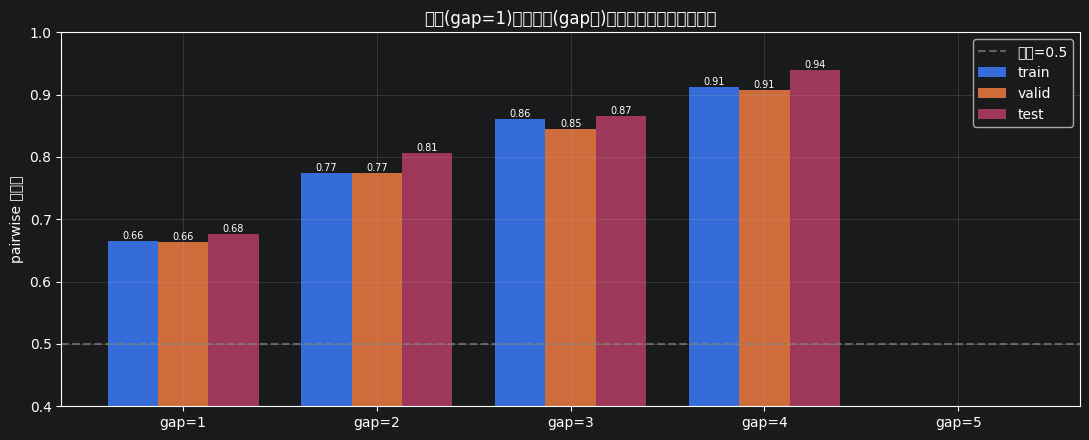

In [17]:
# 相邻名次排序诊断：按共识名次差 (gap) 分桶的 pairwise 准确率
# gap = 同组两条路线在共识名次里的距离。gap=1 相邻（最难、最值钱），gap 越大越易分。
def gap_bucketed_pairwise(groups_by_split, max_gap: int = 5):
    checkpoint_path = OUTPUT_DIR / "route-preference.pt"
    if not checkpoint_path.exists():
        display(Markdown(f"没有找到当前模型：`{checkpoint_path}`"))
        return None
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    model = RoutePreferenceModel(model_config_from_checkpoint(checkpoint))
    model.load_state_dict(checkpoint["stateDict"])
    model.eval()

    device = torch.device("cpu")
    stats = {sp: defaultdict(lambda: [0, 0]) for sp in groups_by_split}  # gap -> [correct, total]
    overall = {sp: [0, 0] for sp in groups_by_split}
    with torch.no_grad():
        for split_name, split_groups in groups_by_split.items():
            for group in split_groups:
                batch = next(iter_batches((group,), 1, shuffle=False, seed=SEED, device=device))
                if batch.pair_chosen_index.numel() == 0:
                    continue
                output = model(
                    batch.stop_matrix,
                    batch.segment_matrix,
                    batch.route_derived_vector,
                    batch.context_cross_vector,
                    batch.intra_set_vector,
                )
                scores = output.route_preference_score
                # 单组 batch：pair 索引即组内共识名次（items 已按共识名次排序），gap = |名次差|
                for chosen_idx, rejected_idx in zip(
                    batch.pair_chosen_index.tolist(), batch.pair_rejected_index.tolist()
                ):
                    correct = 1 if scores[chosen_idx] > scores[rejected_idx] else 0
                    gap = abs(rejected_idx - chosen_idx)
                    stats[split_name][gap][0] += correct
                    stats[split_name][gap][1] += 1
                    overall[split_name][0] += correct
                    overall[split_name][1] += 1
    return stats, overall, max_gap


_gap_result = gap_bucketed_pairwise(SPLIT_GROUPS, max_gap=5)
if _gap_result is not None:
    gap_stats, gap_overall, MAX_GAP = _gap_result
    gaps = list(range(1, MAX_GAP + 1))
    splits_order = [name for name in ["train", "valid", "test"] if name in gap_stats]

    table_rows = []
    for split_name in splits_order:
        row = {"split": split_name}
        correct_total, total = gap_overall[split_name]
        row["overall"] = round(correct_total / total, 4) if total else None
        for gap in gaps:
            correct, count = gap_stats[split_name].get(gap, [0, 0])
            row[f"gap={gap}"] = f"{correct / count:.3f} (n={count})" if count else "—"
        table_rows.append(row)
    show_table(table_rows, "按共识名次差分桶的 pairwise 准确率（gap=1 最相邻、最难）")

    fig, ax = plt.subplots(figsize=(11, 4.5))
    width = 0.26
    positions = list(range(len(gaps)))
    for series_index, split_name in enumerate(splits_order):
        accuracies = []
        for gap in gaps:
            correct, count = gap_stats[split_name].get(gap, [0, 0])
            accuracies.append(correct / count if count else 0.0)
        offsets = [pos + (series_index - (len(splits_order) - 1) / 2) * width for pos in positions]
        bars = ax.bar(offsets, accuracies, width=width, label=split_name)
        for rect, gap in zip(bars, gaps):
            count = gap_stats[split_name].get(gap, [0, 0])[1]
            if count:
                ax.annotate(
                    f"{rect.get_height():.2f}",
                    (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                    ha="center", va="bottom", fontsize=7,
                )
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="随机=0.5")
    ax.set_xticks(positions)
    ax.set_xticklabels([f"gap={gap}" for gap in gaps])
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel("pairwise 准确率")
    ax.set_title("相邻(gap=1)最难、远(gap大)易分；用于定位排序瓶颈")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 如何解读

- 如果 train split 的某个 reason code 正样本少于 30，优先补该 code 的数据，不要靠调参硬救。
- 如果 candidate set 数量很少，优先补新的 candidate set；route 数多但 candidate set 少，泛化仍然不稳。
- 如果 train 指标继续涨、valid 指标早早见顶，优先使用 `best_metric` / early stopping，而不是继续加大模型。
- `acceptedReasonFalsePositiveRate@issueThreshold` 使用 0.5 阈值，是偏严格的诊断；实际预测对 good route 会用 `HIGH_ISSUE_THRESHOLD=0.8`。
